<a href="https://colab.research.google.com/github/Nilufar-Komil/Applications-of-the-Generalized-Stiefel-Manifold-in-NN/blob/main/wrn_28_10_%2B_stiefel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.nn as nn
import random
import torch # Main PyTorch Library
import torchvision # Pytorch library for image analysis
from torchvision import transforms  # Transform function used to modify and preprocess all the images
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from torch.utils.data import random_split #Used to split data sets
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [2]:
import torchvision.transforms as transforms

# Normalize all images: shift pixel values within -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=True,                     # use training data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=False,                    # use test data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

# print size of each data sets
print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [00:04<00:00, 41.4MB/s]


Train size: 50000
Test size: 10000


In [3]:
!pip install nested-dict

  Preparing metadata (setup.py) ... done
  Created wheel for nested-dict: filename=nested_dict-1.61-py3-none-any.whl size=6428 sha256=6fff00d88bde79b647ab395cc36a1938236062bed69f25d20915917e91057b1f
  Stored in directory: /root/.cache/pip/wheels/80/29/c9/f0cda370d66969f99b58885cc5e62f2995a2f6d7ea7386d7fb
Successfully built nested-dict


In [4]:
# split full training data set to training and validation parts
train_size = int(0.8 * len(full_train_dataset))   # 80% for training
val_size = len(full_train_dataset) - train_size   # 20% for validation

train_dataset, val_dataset = random_split(
    full_train_dataset,             # dataset to split
    [train_size, val_size],         # sizes of split parts
    generator=torch.Generator().manual_seed(42)   # makes the train/validation split stay the same every time
)

# printing each data sets sizes
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 40000
Val size: 10000
Test size: 10000


In [5]:
batch_size = 64


torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
#data loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffled train batches
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # validation batches
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)    # test batches


In [7]:
class WRNBasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.use_shortcut_conv = (in_channels != out_channels) or (stride != 1)

        self.bn0 = nn.BatchNorm2d(in_channels)
        self.conv0 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv1 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )

        self.convdim = None
        if self.use_shortcut_conv:
            self.convdim = nn.Conv2d(
                in_channels, out_channels,
                kernel_size=1, stride=stride, padding=0, bias=False
            )

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.conv0.weight)
        nn.init.orthogonal_(self.conv1.weight)
        if self.convdim is not None:
            nn.init.orthogonal_(self.convdim.weight)

        nn.init.ones_(self.bn0.weight)
        nn.init.zeros_(self.bn0.bias)
        nn.init.ones_(self.bn1.weight)
        nn.init.zeros_(self.bn1.bias)

    def forward(self, x):
        o1 = F.relu(self.bn0(x), inplace=True)

        y = self.conv0(o1)
        o2 = F.relu(self.bn1(y), inplace=True)
        o2 = F.dropout(o2, p=self.dropout, training=self.training)
        z = self.conv1(o2)

        shortcut = self.convdim(o1) if self.convdim is not None else x
        return z + shortcut

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WRNGroup(nn.Module):
    def __init__(self, num_blocks, in_channels, out_channels, first_stride, dropout=0.3):
        super().__init__()
        blocks = []
        for i in range(num_blocks):
            stride = first_stride if i == 0 else 1
            block_in = in_channels if i == 0 else out_channels
            blocks.append(
                WRNBasicBlock(
                    in_channels=block_in,
                    out_channels=out_channels,
                    stride=stride,
                    dropout=dropout,
                )
            )
        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):
        return self.blocks(x)


class WideResNet(nn.Module):
    def __init__(self, depth=28, width=10, num_classes=10, dropout=0.3):
        super().__init__()
        assert (depth - 4) % 6 == 0, "depth should be 6n+4"

        n = (depth - 4) // 6
        widths = [16 * width, 32 * width, 64 * width]

        self.conv0 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)

        self.group0 = WRNGroup(
            num_blocks=n, in_channels=16, out_channels=widths[0],
            first_stride=1, dropout=dropout
        )
        self.group1 = WRNGroup(
            num_blocks=n, in_channels=widths[0], out_channels=widths[1],
            first_stride=2, dropout=dropout
        )
        self.group2 = WRNGroup(
            num_blocks=n, in_channels=widths[1], out_channels=widths[2],
            first_stride=2, dropout=dropout
        )

        self.bn = nn.BatchNorm2d(widths[2])
        self.fc = nn.Linear(widths[2], num_classes)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.orthogonal_(self.conv0.weight)
        nn.init.ones_(self.bn.weight)
        nn.init.zeros_(self.bn.bias)

        nn.init.normal_(self.fc.weight, mean=0.0, std=2 / (self.fc.in_features ** 0.5))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        x = self.conv0(x)
        x = self.group0(x)
        x = self.group1(x)
        x = self.group2(x)
        x = F.relu(self.bn(x), inplace=True)
        x = F.avg_pool2d(x, 8, 1, 0)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [9]:
model = WideResNet(
    depth=28,
    width=10,
    num_classes=10,
    dropout=0.3,
).to(device)

In [10]:
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss

In [11]:

# Split parameters into Stiefel and normal parameters
stiefel_params = []
normal_params = []

stiefel_param_ids = set()

for module_name, module in model.named_modules():

    # Put only 3x3 Conv2d weights on Stiefel
    # Keep shortcut 1x1 convs, BatchNorm, fc, and biases normal
    if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
        if module.weight.requires_grad:
            stiefel_params.append(module.weight)
            stiefel_param_ids.add(id(module.weight))

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue

    if id(p) not in stiefel_param_ids:
        normal_params.append(p)

print("Number of Stiefel parameter tensors:", len(stiefel_params))
print("Number of normal parameter tensors:", len(normal_params))

Number of Stiefel parameter tensors: 25
Number of normal parameter tensors: 55


In [13]:

from stiefel_optimizer_modify import AdamG

optimizer = AdamG([
    {
        "params": stiefel_params,
        "lr": 0.01,
        "momentum": 0.9,
        "stiefel": True,
        "weight_decay": 1e-4
    },
    {
        "params": normal_params,
        "lr": 0.01,
        "momentum": 0.9,
        "stiefel": False,
        "weight_decay": 1e-4,
        "dampening": 0,
        "nesterov": False
    }
])

#***Training***
We store training and validation's loss and accuracy in per epoch. And visualize them as a plot graph.

In [ ]:
EPOCHS = 15
# Lists to store loss and accuracy values after each epoch
total_loss_train_plot_cayAdam = []         # will store average training loss for each epoch
total_loss_validation_plot_cayAdam = []    # will store average validation loss for each epoch
total_acc_train_plot_cayAdam = []          # will store training accuracy (%) for each epoch
total_acc_validation_plot_cayAdam = []     # will store validation accuracy (%) for each epoch


# Loop over the dataset multiple times
for epoch in range(EPOCHS):

    # Set the model to training mode
    # This is important for layers like Dropout and BatchNorm
    model.train()

    # Initialize variables to accumulate training loss and accuracy
    total_acc_train = 0
    total_loss_train = 0

    # Initialize variables to accumulate validation loss and accuracy
    total_loss_val = 0
    total_acc_val = 0

    # -------------------- TRAINING LOOP --------------------
    for inputs, labels in train_loader:

        # Move input images and labels to the selected device (CPU or GPU)
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Reset gradients from previous batch
        optimizer.zero_grad()

        # Forward pass:
        # send input images through the model to get predictions
        outputs = model(inputs)

        # Compute training loss by comparing predictions with true labels
        train_loss = criterion(outputs, labels)

        # Add current batch loss to total training loss
        total_loss_train += train_loss.item()

        # Backward pass:
        # compute gradients of the loss with respect to model parameters
        train_loss.backward()

        # Compute number of correct predictions in this batch
        train_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()

        # Add batch correct predictions to total training correct predictions
        total_acc_train += train_acc

        # Update model parameters using optimizer
        optimizer.step()

    # -------------------- VALIDATION LOOP --------------------
    # Set model to evaluation mode
    model.eval()

    # Disable gradient calculation for validation
    # This saves memory and computation
    with torch.no_grad():
        for inputs, labels in val_loader:

            # Move validation batch to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = model(inputs)

            # Compute validation loss
            val_loss = criterion(outputs, labels)

            # Add current batch loss to total validation loss
            total_loss_val += val_loss.item()

            # Compute number of correct validation predictions
            val_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()

            # Add batch correct predictions to total validation correct predictions
            total_acc_val += val_acc

    # Compute average training loss across all training batches
    avg_train_loss = total_loss_train / len(train_loader)

    # Compute average validation loss across all validation batches
    avg_val_loss = total_loss_val / len(val_loader)

    # Compute training accuracy as percentage
    avg_train_acc = (total_acc_train / len(train_dataset)) * 100

    # Compute validation accuracy as percentage
    avg_val_acc = (total_acc_val / len(val_dataset)) * 100

    # Store rounded values for plotting later
    total_loss_train_plot_cayAdam.append(round(avg_train_loss, 4))
    total_loss_validation_plot_cayAdam.append(round(avg_val_loss, 4))
    total_acc_train_plot_cayAdam.append(round(avg_train_acc, 4))
    total_acc_validation_plot_cayAdam.append(round(avg_val_acc, 4))

    # Print epoch results
    print(f"Epoch {epoch+1}/{EPOCHS}, "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Train Accuracy: {avg_train_acc:.4f}%, "
          f"Validation Loss: {avg_val_loss:.4f}, "
          f"Validation Accuracy: {avg_val_acc:.4f}%")

    print("=" * 25)

Epoch 1/15, Train Loss: 1.7851, Train Accuracy: 32.7600%, Validation Loss: 2.8245, Validation Accuracy: 19.5500%
Epoch 2/15, Train Loss: 1.4572, Train Accuracy: 46.2775%, Validation Loss: 3.0282, Validation Accuracy: 26.6600%


#***Testing***
After training we test our model on test dataset.

In [ ]:
with torch.no_grad():
  total_loss_test_cayAdam = 0
  total_acc_test_cayAdam = 0
  for inputs, labels in test_loader:
    inputs = inputs.to(device)  # Move inputs to the correct device
    labels = labels.to(device)  # Move labels to the correct device
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test_cayAdam += acc
    test_loss = criterion(predictions, labels)
    total_loss_test_cayAdam += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test_cayAdam/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test_cayAdam/len(test_loader), 4)}")

Accuracy Score is: 29.02 and Loss is 1.9749


#***Plotting results***
We plot loss and accuracy of training and validation data set. There will be two kind of problems: overfitting and underfitting.

## Overfitting and Underfitting

### Overfitting
Overfitting occurs when a model learns the training data too closely, including noise and unnecessary details. Because of this, it performs very well on training data but poorly on new, unseen data.

**Common signs:**
- High training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use more training data
- Reduce model complexity
- Apply regularization
- Use dropout
- Stop training early

---

### Underfitting
Underfitting occurs when a model is too simple to learn the underlying patterns in the data. As a result, it performs poorly on both training data and unseen data.

**Common signs:**
- Low training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use a more powerful model
- Train for more epochs
- Add better input features
- Reduce excessive regularization

---

### Summary
- **Overfitting:** good performance on training data, poor performance on new data  
- **Underfitting:** poor performance on both training data and new data

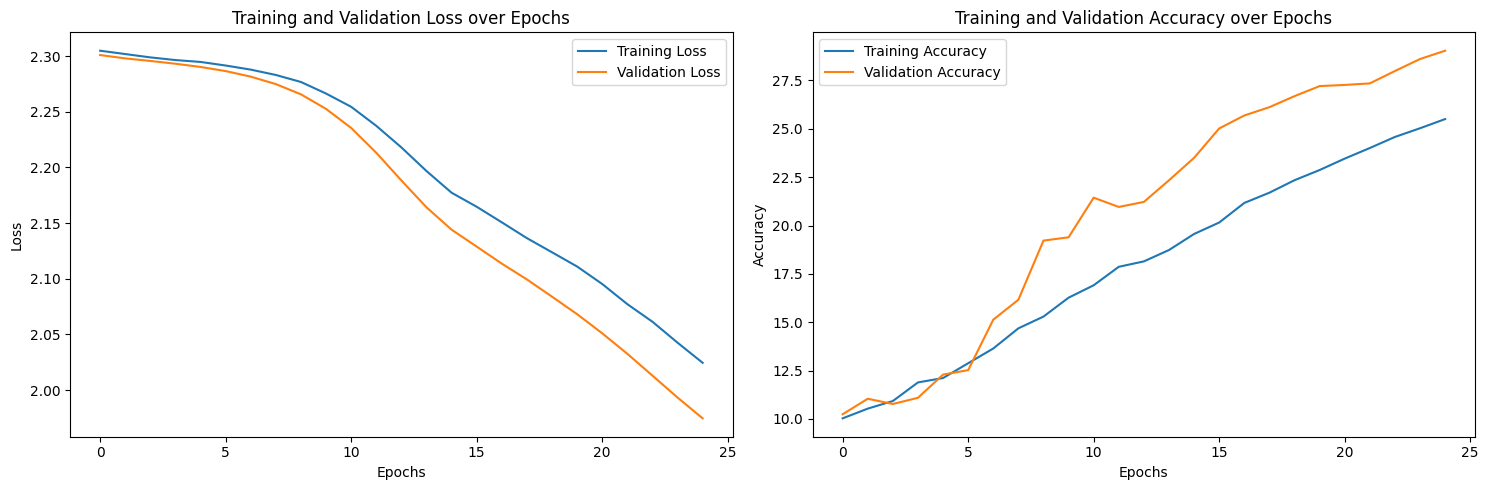

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot_cayAdam, label='Training Loss')
axs[0].plot(total_loss_validation_plot_cayAdam, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot_cayAdam, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot_cayAdam, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

##**SGDG optimization method's results**

In [ ]:
from stiefel_optimizer_modify import SGDG

optimizer = SGDG([
    {
        "params": stiefel_params,
        "lr": LR,
        "momentum": 0.9,
        "stiefel": True,
        "weight_decay": 1e-4
    },
    {
        "params": normal_params,
        "lr": LR,
        "momentum": 0.9,
        "stiefel": False,
        "weight_decay": 1e-4,
        "dampening": 0,
        "nesterov": False
    }
])

#------------- TRAINING----------------------------------------------------



In [ ]:
# Lists to store loss and accuracy values after each epoch
total_loss_train_plot_caySGDG = []         # will store average training loss for each epoch
total_loss_validation_plot_caySGDG = []    # will store average validation loss for each epoch
total_acc_train_plot_caySGDG = []          # will store training accuracy (%) for each epoch
total_acc_validation_plot_caySGDG = []     # will store validation accuracy (%) for each epoch


# Loop over the dataset multiple times
for epoch in range(EPOCHS):

    # Set the model to training mode
    # This is important for layers like Dropout and BatchNorm
    model.train()

    # Initialize variables to accumulate training loss and accuracy
    total_acc_train = 0
    total_loss_train = 0

    # Initialize variables to accumulate validation loss and accuracy
    total_loss_val = 0
    total_acc_val = 0

    # -------------------- TRAINING LOOP --------------------
    for inputs, labels in train_loader:

        # Move input images and labels to the selected device (CPU or GPU)
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Reset gradients from previous batch
        optimizer.zero_grad()

        # Forward pass:
        # send input images through the model to get predictions
        outputs = model(inputs)

        # Compute training loss by comparing predictions with true labels
        train_loss = criterion(outputs, labels)

        # Add current batch loss to total training loss
        total_loss_train += train_loss.item()

        # Backward pass:
        # compute gradients of the loss with respect to model parameters
        train_loss.backward()

        # Compute number of correct predictions in this batch
        train_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()

        # Add batch correct predictions to total training correct predictions
        total_acc_train += train_acc

        # Update model parameters using optimizer
        optimizer.step()

    # -------------------- VALIDATION LOOP --------------------
    # Set model to evaluation mode
    model.eval()

    # Disable gradient calculation for validation
    # This saves memory and computation
    with torch.no_grad():
        for inputs, labels in val_loader:

            # Move validation batch to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = model(inputs)

            # Compute validation loss
            val_loss = criterion(outputs, labels)

            # Add current batch loss to total validation loss
            total_loss_val += val_loss.item()

            # Compute number of correct validation predictions
            val_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()

            # Add batch correct predictions to total validation correct predictions
            total_acc_val += val_acc

    # Compute average training loss across all training batches
    avg_train_loss = total_loss_train / len(train_loader)

    # Compute average validation loss across all validation batches
    avg_val_loss = total_loss_val / len(val_loader)

    # Compute training accuracy as percentage
    avg_train_acc = (total_acc_train / len(train_dataset)) * 100

    # Compute validation accuracy as percentage
    avg_val_acc = (total_acc_val / len(val_dataset)) * 100

    # Store rounded values for plotting later
    total_loss_train_plot_caySGDG.append(round(avg_train_loss, 4))
    total_loss_validation_plot_caySGDG.append(round(avg_val_loss, 4))
    total_acc_train_plot_caySGDG.append(round(avg_train_acc, 4))
    total_acc_validation_plot_caySGDG.append(round(avg_val_acc, 4))

    # Print epoch results
    print(f"Epoch {epoch+1}/{EPOCHS}, "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Train Accuracy: {avg_train_acc:.4f}%, "
          f"Validation Loss: {avg_val_loss:.4f}, "
          f"Validation Accuracy: {avg_val_acc:.4f}%")

    print("=" * 25)

Epoch 1/25, Train Loss: 2.3041, Train Accuracy: 9.9175%, Validation Loss: 2.3023, Validation Accuracy: 9.9900%
Epoch 2/25, Train Loss: 2.3019, Train Accuracy: 10.3600%, Validation Loss: 2.2991, Validation Accuracy: 10.0700%
Epoch 3/25, Train Loss: 2.2997, Train Accuracy: 11.0125%, Validation Loss: 2.2964, Validation Accuracy: 11.3500%
Epoch 4/25, Train Loss: 2.2972, Train Accuracy: 11.4550%, Validation Loss: 2.2936, Validation Accuracy: 12.8200%
Epoch 5/25, Train Loss: 2.2946, Train Accuracy: 12.0425%, Validation Loss: 2.2903, Validation Accuracy: 13.4500%
Epoch 6/25, Train Loss: 2.2913, Train Accuracy: 12.7550%, Validation Loss: 2.2864, Validation Accuracy: 13.5600%
Epoch 7/25, Train Loss: 2.2870, Train Accuracy: 13.4050%, Validation Loss: 2.2813, Validation Accuracy: 15.9600%
Epoch 8/25, Train Loss: 2.2823, Train Accuracy: 14.5350%, Validation Loss: 2.2746, Validation Accuracy: 17.4000%
Epoch 9/25, Train Loss: 2.2747, Train Accuracy: 15.6400%, Validation Loss: 2.2651, Validation Accu

In [ ]:
with torch.no_grad():
  total_loss_test_caySGDG = 0
  total_acc_test_caySGDG = 0
  for inputs, labels in test_loader:
    inputs = inputs.to(device)  # Move inputs to the correct device
    labels = labels.to(device)  # Move labels to the correct device
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test_caySGDG += acc
    test_loss = criterion(predictions, labels)
    total_loss_test_caySGDG += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test_caySGDG/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test_caySGDG/len(test_loader), 4)}")

Accuracy Score is: 30.61 and Loss is 1.9026


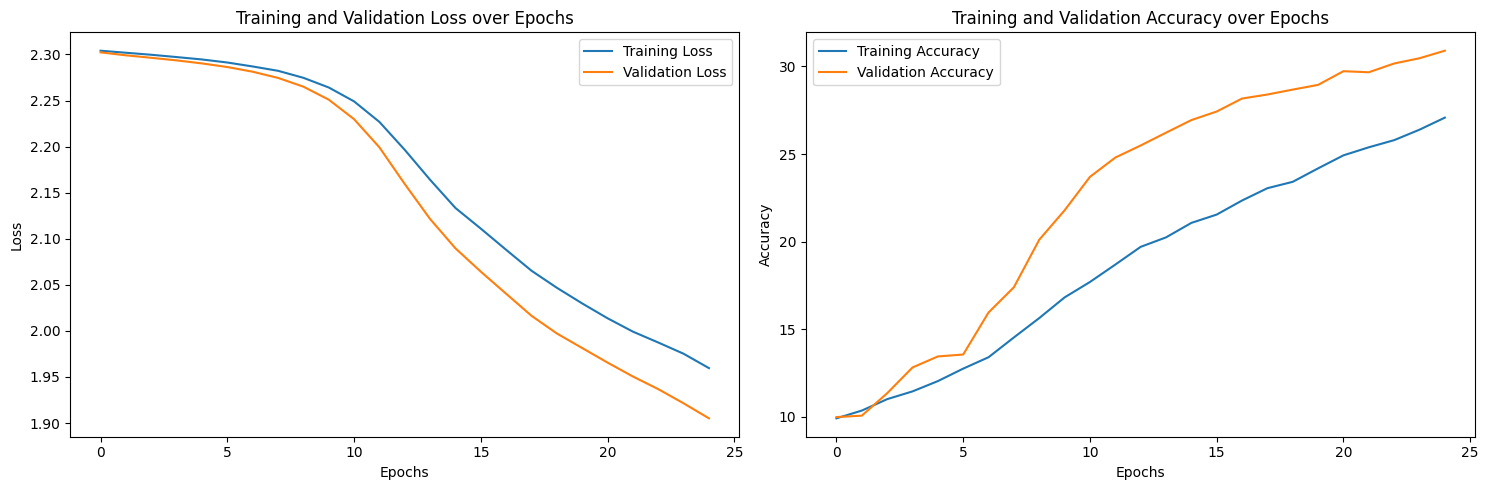

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot_caySGDG, label='Training Loss')
axs[0].plot(total_loss_validation_plot_caySGDG, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot_caySGDG, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot_caySGDG, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

#***Comparing Methods***


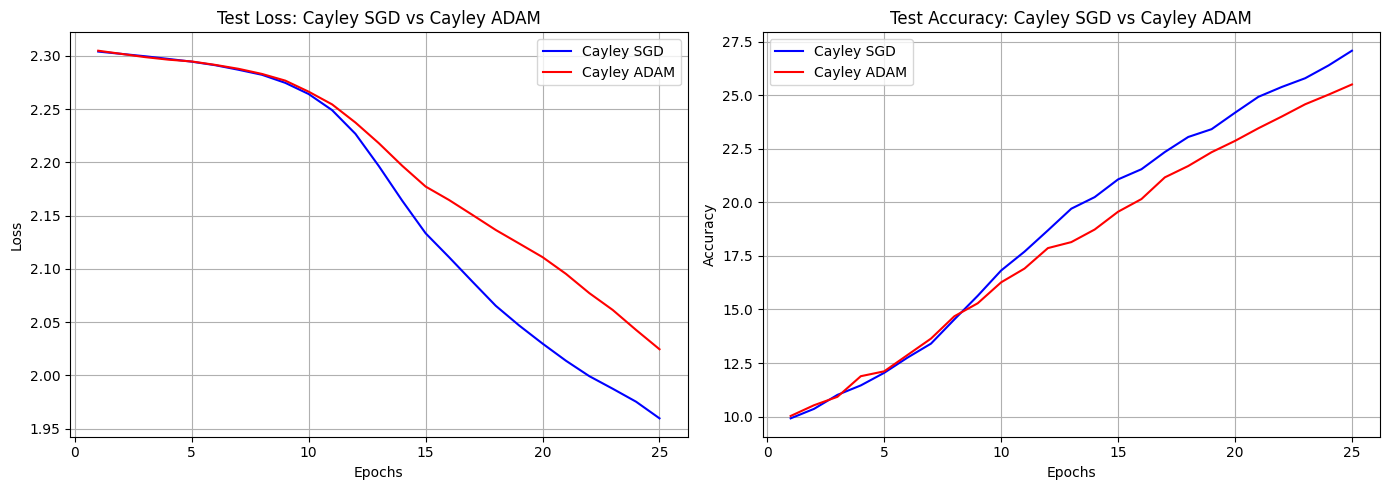

In [ ]:

epochs = range(1, len(total_acc_validation_plot_caySGDG) + 1)

plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(epochs, total_loss_train_plot_caySGDG, label="Cayley SGD", color="blue")
plt.plot(epochs, total_loss_train_plot_cayAdam, label="Cayley ADAM", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Test Loss: Cayley SGD vs Cayley ADAM")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(epochs, total_acc_train_plot_caySGDG, label="Cayley SGD", color="blue")
plt.plot(epochs, total_acc_train_plot_cayAdam, label="Cayley ADAM", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Test Accuracy: Cayley SGD vs Cayley ADAM")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


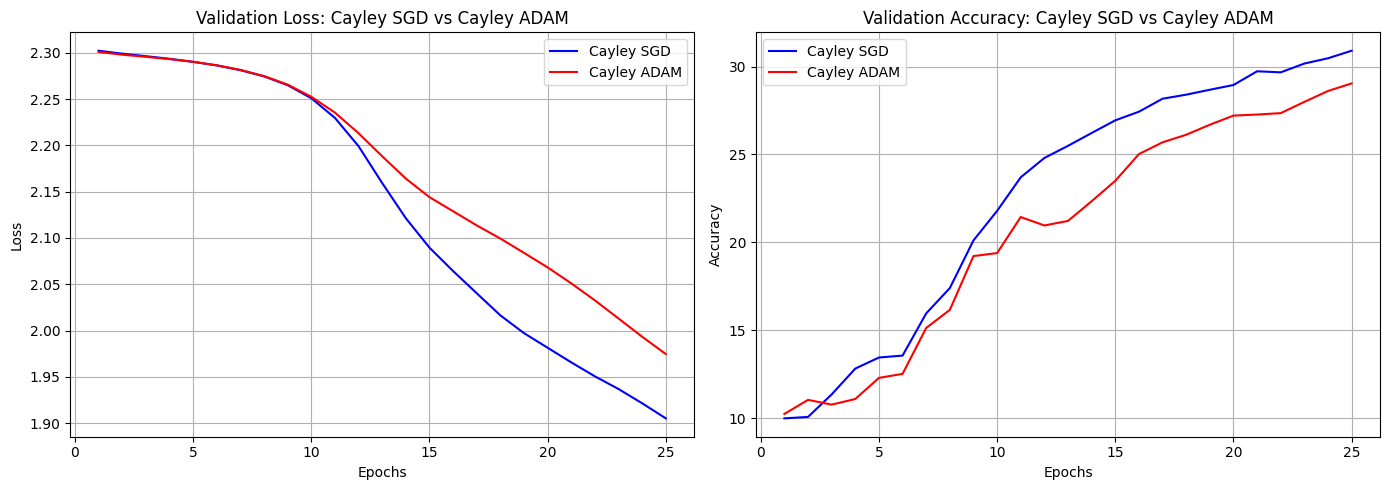

In [ ]:

epochs = range(1, len(total_acc_validation_plot_caySGDG) + 1)

plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(epochs, total_loss_validation_plot_caySGDG, label="Cayley SGD", color="blue")
plt.plot(epochs, total_loss_validation_plot_cayAdam, label="Cayley ADAM", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss: Cayley SGD vs Cayley ADAM")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(epochs, total_acc_validation_plot_caySGDG, label="Cayley SGD", color="blue")
plt.plot(epochs, total_acc_validation_plot_cayAdam, label="Cayley ADAM", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: Cayley SGD vs Cayley ADAM")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
